# Phys 610 Midterm
## Problems 6-8
### Sean Ericson

In [236]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

In [237]:
def f1(y, M, b):
    t, t_dot, r, r_dot, theta, theta_dot, phi, phi_dot = y
    tmp1 = r*r + b*b
    return -2 * M * r * r_dot * t_dot / (tmp1 * np.sqrt(tmp1 - 2*M))

def f2(y, M, b):
    t, t_dot, r, r_dot, theta, theta_dot, phi, phi_dot = y
    tmp1 = r*r + b*b
    tmp2 = np.sqrt(tmp1 - 2*M)
    return r * (tmp2*tmp2*(np.power(tmp1, 3/2)*(np.power(np.sin(theta), 2)*phi_dot*phi_dot + theta_dot*theta_dot) - M*t_dot*t_dot) + M*tmp1*r_dot*r_dot) / (tmp1*tmp1*tmp2)

def f3(y, M, b):
    t, t_dot, r, r_dot, theta, theta_dot, phi, phi_dot = y
    tmp1 = r*r + b*b
    return np.sin(theta)*np.cos(theta)*phi_dot*phi_dot - 2*r*r_dot*theta_dot/tmp1

def f4(y, M, b):
    t, t_dot, r, r_dot, theta, theta_dot, phi, phi_dot = y
    tmp1 = r*r + b*b
    return 2*phi_dot*(theta_dot/np.tan(theta) + r*r_dot/tmp1)

def f(t, y, M, b):
    return (y[1], f1(y, M, b), y[3], f2(y, M, b), y[5], f3(y, M, b), y[7], f4(y, M, b))

In [238]:
y0 = (0, 1, 10, 0, np.pi/2, 0, 0, 0.03)
M = 1
b = 1
t_min = 0
t_max = 100
result = solve_ivp(f, (t_min, t_max), y0, args=(M,b))

C:\Users\Sean\AppData\Local\Temp\ipykernel_13676\3252337920.py:4: RuntimeWarning: invalid value encountered in sqrt
  return -2 * M * r * r_dot * t_dot / (tmp1 * np.sqrt(tmp1 - 2*M))
C:\Users\Sean\AppData\Local\Temp\ipykernel_13676\3252337920.py:9: RuntimeWarning: invalid value encountered in sqrt
  tmp2 = np.sqrt(tmp1 - 2*M)


In [239]:
result

  message: Required step size is less than spacing between numbers.
  success: False
   status: -1
        t: [ 0.000e+00  1.982e-03 ...  5.992e+01  5.992e+01]
        y: [[ 0.000e+00  1.982e-03 ...  6.553e+01  6.553e+01]
            [ 1.000e+00  1.000e+00 ...  7.557e+00  7.557e+00]
            ...
            [ 0.000e+00  5.947e-05 ...  1.358e+00  1.358e+00]
            [ 3.000e-02  3.000e-02 ...  5.943e-04  5.943e-04]]
      sol: None
 t_events: None
 y_events: None
     nfev: 518
     njev: 0
      nlu: 0

In [240]:
result.y[2]

array([10.        , 10.        ,  9.9999998 ,  9.99997958,  9.99794914,
        9.92018581,  9.48776145,  7.16147492,  6.10032566,  4.59683185,
        3.89575587,  3.03768992,  2.58725204,  2.05816033,  1.78884581,
        1.48500663,  1.33565273,  1.17615719,  1.09599651,  1.01616743,
        1.01138939,  1.00666827,  1.00119989,  1.00013231,  1.00009005,
        1.00004785,  1.00003476,  1.00002169,  1.00001646,  1.00001124,
        1.0000008 ,  1.00000038,  1.0000003 ,  1.00000022,  1.00000005,
        1.00000002,  1.00000001,  1.        ,  1.        ,  1.        ,
        1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
        1.        ,  1.        ,  1.        ,  1.        ,  1.        ])

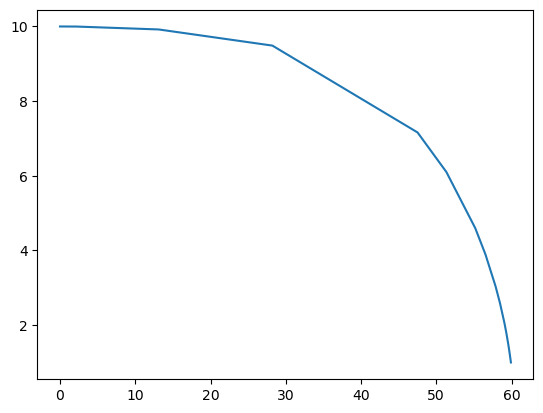

In [241]:
plt.plot(result.t, result.y[2])

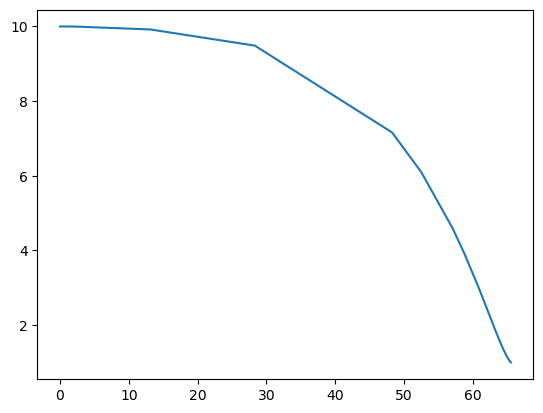

In [242]:
plt.plot(result.y[0], result.y[2])

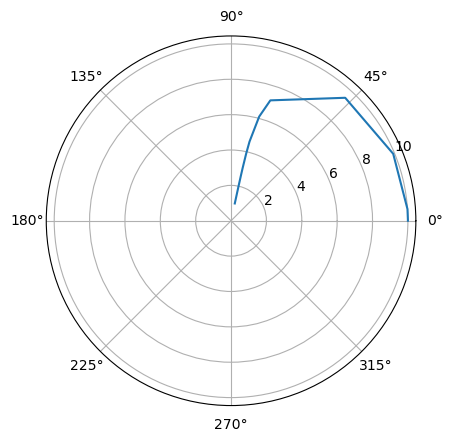

In [243]:
#Make plt figure
fig = plt.figure()

#Make sub-plot with attribute "polar"
ax = fig.add_subplot(polar=True)

#Plot function
ax.plot(result.y[6], result.y[2])